In [1]:
#imports and data load
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from math import sqrt
import sys
import os
os.chdir("D:/Project/EV Range Intelligence System")
sys.path.append("D:/Project/EV Range Intelligence System")

from src.data_pipeline import load_data, feature_engineering, split_and_scale

# Load processed data
df = load_data()
X, y, df_all = feature_engineering(df)
X_train, X_val, y_train, y_val, scaler = split_and_scale(X, y)

print("Train shape:", X_train.shape)

Train shape: (8000, 15)


In [2]:
#2. Define a Quantile Model Trainer
def train_quantile_models(X_train, y_train, quantiles=[0.1, 0.5, 0.9]):
    models = {}
    for q in quantiles:
        print(f"Training quantile model for α={q}")
        params = {
            "objective": "quantile",
            "alpha": q,
            "metric": "mae",
            "verbosity": -1,
            "num_leaves": 31,
            "learning_rate": 0.05,
            "feature_fraction": 0.9,
        }
        dtrain = lgb.Dataset(X_train, label=y_train)
        model = lgb.train(params, dtrain, num_boost_round=400)
        models[q] = model
    return models


def predict_quantiles(models, X):
    preds = {}
    for q in models:
        preds[q] = models[q].predict(X)
    return preds

In [3]:
#Train Quantile Models
models = train_quantile_models(X_train, y_train)
preds = predict_quantiles(models, X_val)

pred_df = pd.DataFrame({
    "y_true": y_val,
    "q10": preds[0.1],
    "q50": preds[0.5],
    "q90": preds[0.9],
})
pred_df.head()

Training quantile model for α=0.1
Training quantile model for α=0.5
Training quantile model for α=0.9


,y_true,q10,q50,q90
6252,155.371659,144.239254,148.206512,154.807904
4684,165.192098,156.148779,160.973249,165.592175
1731,161.925448,152.595387,155.545437,162.257079
4742,152.101907,145.939612,147.717863,155.517036
4521,144.013964,142.370836,146.347926,154.590672


In [4]:
#4. Evaluate Model Performance
mae = mean_absolute_error(pred_df["y_true"], pred_df["q50"])
rmse = sqrt(mean_squared_error(pred_df["y_true"], pred_df["q50"]))
print(f"MAE: {mae:.2f} Wh/km | RMSE: {rmse:.2f} Wh/km")

coverage = ((pred_df["y_true"] >= pred_df["q10"]) & (pred_df["y_true"] <= pred_df["q90"])).mean()
print(f"Calibration coverage (should be ~0.8): {coverage:.2f}")

MAE: 4.23 Wh/km | RMSE: 5.30 Wh/km
Calibration coverage (should be ~0.8): 0.69


In [5]:
#5. Convert Wh/km → Predicted Range (km)
battery_kwh = 60
soc = 80   # current state-of-charge (%)
soh = 0.9  # battery health (90%)

available_kwh = battery_kwh * soh * soc / 100

pred_df["range_safe_km"] = (available_kwh * 1000) / pred_df["q90"]
pred_df["range_expected_km"] = (available_kwh * 1000) / pred_df["q50"]
pred_df["range_optimistic_km"] = (available_kwh * 1000) / pred_df["q10"]

pred_df[["range_safe_km","range_expected_km","range_optimistic_km"]].describe()

,range_safe_km,range_expected_km,range_optimistic_km
count,2000.000000,2000.000000,2000.000000
mean,277.849719,287.809998,298.696255
std,10.653748,12.355923,12.600957
min,244.123972,250.306111,262.605867
25%,270.487599,278.905902,289.661037
50%,277.675838,287.847114,298.522994
75%,285.088327,296.330183,307.735018
max,309.849349,323.893592,338.353514


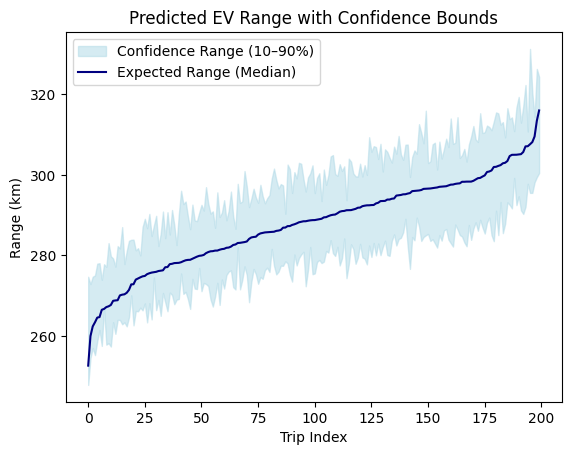

In [6]:
#6. Visualize Confidence-Aware Range
import matplotlib.pyplot as plt

sample = pred_df.sample(200).sort_values("range_expected_km").reset_index(drop=True)
plt.fill_between(sample.index, sample["range_safe_km"], sample["range_optimistic_km"], color="lightblue", alpha=0.5, label="Confidence Range (10–90%)")
plt.plot(sample.index, sample["range_expected_km"], color="navy", label="Expected Range (Median)")
plt.title("Predicted EV Range with Confidence Bounds")
plt.ylabel("Range (km)")
plt.xlabel("Trip Index")
plt.legend()
plt.show()
